In [11]:
import os
import sys
import pickle
import numpy as np
import torch 
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt

from hydra import initialize, compose

from alpha_blokus.display import Display
from alpha_blokus.moves_data import moves_data
from alpha_blokus.neural_net import NeuralNet
from alpha_blokus.training.load_games import load_game_file
from alpha_blokus.state import State

In [12]:
with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="main_self_play")
    print(cfg)

model = NeuralNet(cfg["networks"]["main"], cfg)
model_unflattened = NeuralNet(cfg["networks"]["main"], cfg, flatten_policy=False)

for m in [model, model_unflattened]:
    m.load_state_dict(torch.load("/Users/shivamsarodia/Dev/BlokusBot/data/2024-12-30_23-23-24-rubefaction/models/008190136.pt", weights_only=True))
    m.eval()

{'entrypoint': 'simulation', 'runtime': 0, 'log_flush_interval': 600, 'log_to_console': False, 'log_made_move': False, 'use_profiler': False, 'game': {'board_size': 20, 'num_moves': 30433, 'num_pieces': 21, 'num_piece_orientations': 91, 'moves_data_path': '/Users/shivamsarodia/Dev/BlokusBot/data/moves_20.npz'}, 'networks': {'main': {'main_body_channels': 64, 'residual_blocks': 10, 'value_head_channels': 16, 'value_head_flat_layer_width': 64, 'policy_head_channels': 64, 'policy_convolution_kernel': 3, 'new_model_check_interval': 120, 'batch_size': 128, 'model_read_path': 'models/', 'initialize_model_if_empty': False, 'log_gpu_evaluation': False}}, 'gameplay': {'architecture': {'gameplay_processes': 6, 'coroutines_per_process': 256}, 'game_save_directory': 'games/', 'game_flush_threshold': 100, 'check_move_validity': True, 'agents': {'0': {'type': 'mcts', 'name': 'mcts', 'network': 'main', 'full_move_probability': 0.2, 'full_move_rollouts': 500, 'fast_move_rollouts': 100, 'ucb_exploratio

In [13]:
state = State(cfg)
valid_moves = state.valid_moves_array()

Computing initial moves enabled...
Loading moves data...
Moves data loaded.


In [49]:
gamedata = load_game_file("/Users/shivamsarodia/Dev/BlokusBot/data/2024-12-30_23-23-24-rubefaction/games/1736785927619_1427.npz")
board = gamedata["boards"][0]

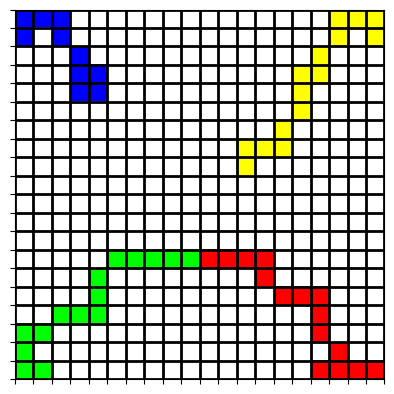

In [50]:
Display(board).show()

In [51]:
values, policy = model_unflattened(torch.Tensor(board).unsqueeze(0))
policy = policy.numpy(force=True)

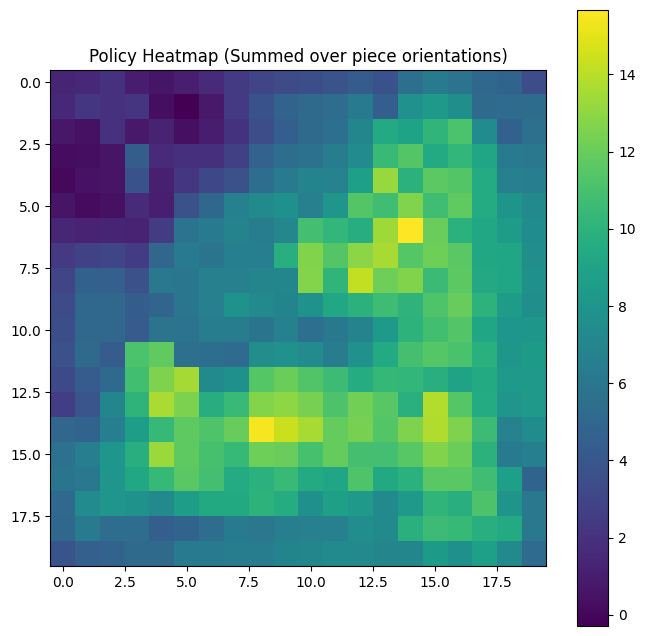

In [52]:
plt.figure(figsize=(8, 8))
plt.imshow(policy[0].max(axis=0), cmap='viridis')
plt.colorbar()
plt.title('Policy Heatmap (Summed over piece orientations)')
plt.show()

In [37]:
np.unravel_index(np.argmax(policy), policy.shape)

(np.int64(0), np.int64(2), np.int64(6), np.int64(14))

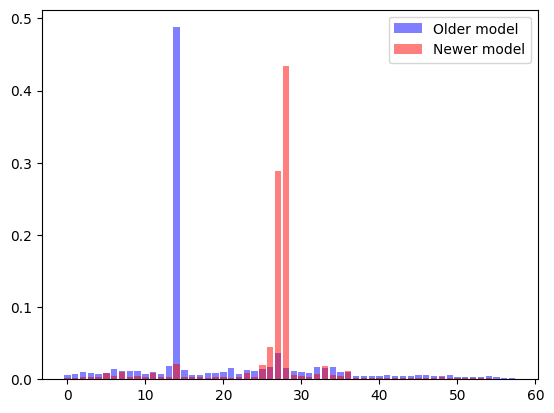

In [12]:
values_logits_newer, policy_logits_newer = model_newer(torch.zeros(1, 4, 20, 20))
policy_logits_newer[0, ~valid_moves] = -1e6
values_newer = torch.softmax(values_logits_newer, dim=1).cpu().numpy(force=True)[0]
policy_newer = torch.softmax(policy_logits_newer, dim=1).cpu().numpy(force=True)[0]

values_logits_older, policy_logits_older = model_older(torch.zeros(1, 4, 20, 20))
policy_logits_older[0, ~valid_moves] = -1e6
values_older = torch.softmax(values_logits_older, dim=1).cpu().numpy(force=True)[0]
policy_older = torch.softmax(policy_logits_older, dim=1).cpu().numpy(force=True)[0]

plt.bar(range(sum(valid_moves)), policy_older[valid_moves], color="blue", alpha=0.5, label="Older model")
plt.bar(range(sum(valid_moves)), policy_newer[valid_moves], color="red", alpha=0.5, label="Newer model")
plt.legend()

In [1]:

board = gamedata["boards"][60]
Display(board).show()

NameError: name 'gamedata' is not defined

In [20]:
result_32b = model(torch.Tensor(board).unsqueeze(0))

In [22]:
result_16b = model.to(torch.float16)(torch.Tensor(board).to(torch.float16).unsqueeze(0))

In [40]:
p16 = torch.softmax(result_16b[1], dim=1).cpu().numpy(force=True)
p32 =torch.softmax(result_32b[1], dim=1).cpu().numpy(force=True)

np.abs(p32[p16 > 0.001] / p16[p16 > 0.001] - 1)

array([1.1111796e-02, 8.7311268e-03, 4.5757294e-03, 2.4750233e-03,
       4.8816204e-05, 2.8219819e-03, 7.5880885e-03, 3.8286448e-03,
       4.8202276e-04, 2.0939708e-03, 3.2237768e-03, 2.2671819e-03,
       1.5487075e-03, 1.9347668e-04, 6.5185428e-03, 4.0165186e-03,
       6.2291622e-03, 1.8113852e-04, 3.2528639e-03, 7.5988770e-03,
       2.2614002e-03, 4.5863390e-03, 3.2122135e-03, 2.8421879e-03,
       1.3028383e-03, 4.6966076e-03, 6.0173869e-03, 6.0850382e-04,
       1.0148883e-03, 5.1057339e-04, 7.3966980e-03, 5.0079823e-04,
       3.0364990e-03, 3.0330420e-03, 8.3446503e-07, 1.0862350e-03,
       3.9577484e-03, 1.2822747e-03, 2.3484230e-04, 5.5109262e-03,
       1.1024475e-03, 6.5460205e-03, 5.9906244e-03, 6.7437887e-03,
       1.2181997e-03, 4.5372248e-03, 4.8810244e-03, 3.7312508e-04,
       7.6712370e-03, 4.8401356e-03, 1.6761422e-03, 9.5150471e-03,
       5.5298805e-03, 7.5685978e-03, 3.7804246e-03, 3.4909248e-03,
       5.0354004e-03, 9.5820427e-03, 2.8113127e-03, 5.2138567e

In [32]:
result_32b[1]

tensor([[ 5.5843,  4.8594,  6.0398,  ..., -3.4182, -3.1603, -3.1409]],
       grad_fn=<IndexBackward0>)

In [30]:
print(torch.softmax(result_32b[0], dim=1).cpu().numpy(force=True))
print(torch.softmax(result_16b[0], dim=1).cpu().numpy(force=True))

[[0.24343032 0.4499887  0.1998059  0.10677509]]
[[0.2426 0.4512 0.1998 0.1064]]


placement_x 4
placement_y 2
piece_orientation_index 16


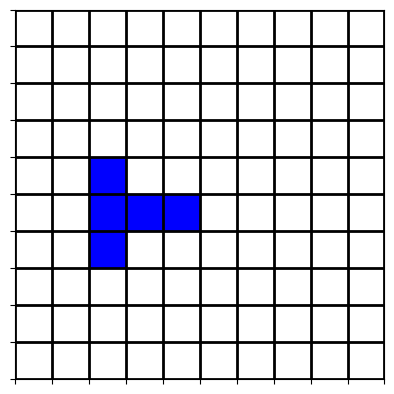

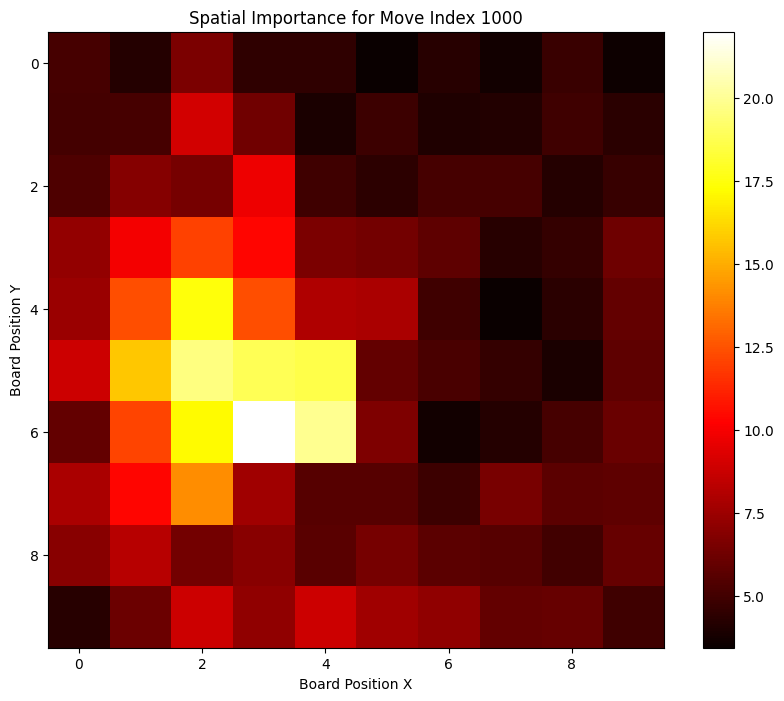

Min importance: 3.429
Max importance: 22.006
Mean importance: 7.248


In [13]:
# Pick a move index to analyze
move_idx = 1000  # Can change this to analyze different moves

board = np.zeros((4, BOARD_SIZE, BOARD_SIZE), dtype=np.bool)
board[0, :, :] = moves_data()["new_occupieds"][move_idx]

print("placement_x", moves_data()["placement_x"][move_idx])
print("placement_y", moves_data()["placement_y"][move_idx])
print("piece_orientation_index", moves_data()["piece_orientation_indices"][move_idx])

Display(board).show()

# Get the weights from the final linear layer for this move
final_conv = model.policy_head[0]  # First conv layer
final_linear = model.policy_head[-1]  # Final linear layer
weights = final_linear.weight[move_idx]  # Get weights for specific move

# Reshape weights to match the conv output shape
conv_channels = final_conv.out_channels
weights = weights.reshape(conv_channels, BOARD_SIZE, BOARD_SIZE)

# Calculate the importance map by taking absolute values and summing across channels
importance_map = weights.abs().sum(dim=0)

# Plot the importance map
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(importance_map.detach().numpy(), cmap='hot')
plt.colorbar()
plt.title(f'Spatial Importance for Move Index {move_idx}')
plt.xlabel('Board Position X')
plt.ylabel('Board Position Y')
plt.show()

# Optional: Print the range of values
print(f"Min importance: {importance_map.min().item():.3f}")
print(f"Max importance: {importance_map.max().item():.3f}")
print(f"Mean importance: {importance_map.mean().item():.3f}")
